# Down-Sampling With vs. Without Anti-Aliasing (Gaussian Pre-Filtering)

### Formulas:

- **Nyquist-Shannon Sampling Theorem:**
  $$f_{\text{max}} \le \frac{f_s}{2}$$
- **Gaussian Pre-Filter Low-Pass Bandwidth Choice:**
  $$\sigma \approx \frac{\text{factor}}{2}, \quad \text{kernel size} = 2 \cdot \lfloor 3\sigma \rfloor + 1$$
- **Mean Squared Error (MSE):**
  $$\text{MSE} = \frac{1}{M \cdot N} \sum_{x=0}^{M-1} \sum_{y=0}^{N-1} \left( I(x,y) - \hat{I}(x,y) \right)^2$$
- **Peak Signal-to-Noise Ratio (PSNR):**
  $$\text{PSNR} = 10 \cdot \log_{10} \left( \frac{MAX_I^2}{\text{MSE}} \right) \quad \text{dB} \quad (\text{where } MAX_I = 255)$$

This notebook:

1. Reads a grayscale image ($\ge 256 \times 256$).
2. Performs direct down-sampling by factors of 2, 4, 8 via pixel skipping (`img[::f, ::f]`).
3. Performs anti-aliased down-sampling using `cv2.GaussianBlur()` prior to sub-sampling.
4. Compares all 6 down-sampled outputs side by side.
5. Reconstructs full-size images using `cv2.INTER_NEAREST` and evaluates MSE & PSNR.
6. Discusses why anti-aliasing pre-filters prevent spatial aliasing artifacts.


In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

## (i) Read or Synthesize Grayscale Image ($\ge 256 \times 256$)


In [2]:
def load_grayscale_image(
    path: str = "images/image1.jpg", size: int = 256
) -> np.ndarray:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    return img


img = load_grayscale_image("images/image1.jpg", size=256)
H, W = img.shape
print(f"Original image size: {H} x {W}, dtype={img.dtype}")

factors = [2, 4, 8]

Original image size: 640 x 612, dtype=uint8


## (ii) Unfiltered Down-Sampling (Direct Pixel Skipping)


In [3]:
unfiltered = {f: img[::f, ::f] for f in factors}

## (iii) Filtered Down-Sampling (Gaussian Anti-Aliasing Pre-Filter)


In [4]:
def gaussian_sigma_for_factor(f: int) -> float:
    # A common rule of thumb: sigma ~ factor / 2 so the low-pass cutoff
    # roughly matches the new Nyquist rate.
    return f / 2.0


filtered = {}
for f in factors:
    sigma = gaussian_sigma_for_factor(f)
    ksize = 2 * int(3 * sigma) + 1  # odd kernel size, ~3 sigma radius
    ksize = max(ksize, 3)
    blurred = cv2.GaussianBlur(img, (ksize, ksize), sigma)
    filtered[f] = blurred[::f, ::f]

## (iv) Display Down-Sampled Comparisons Side by Side


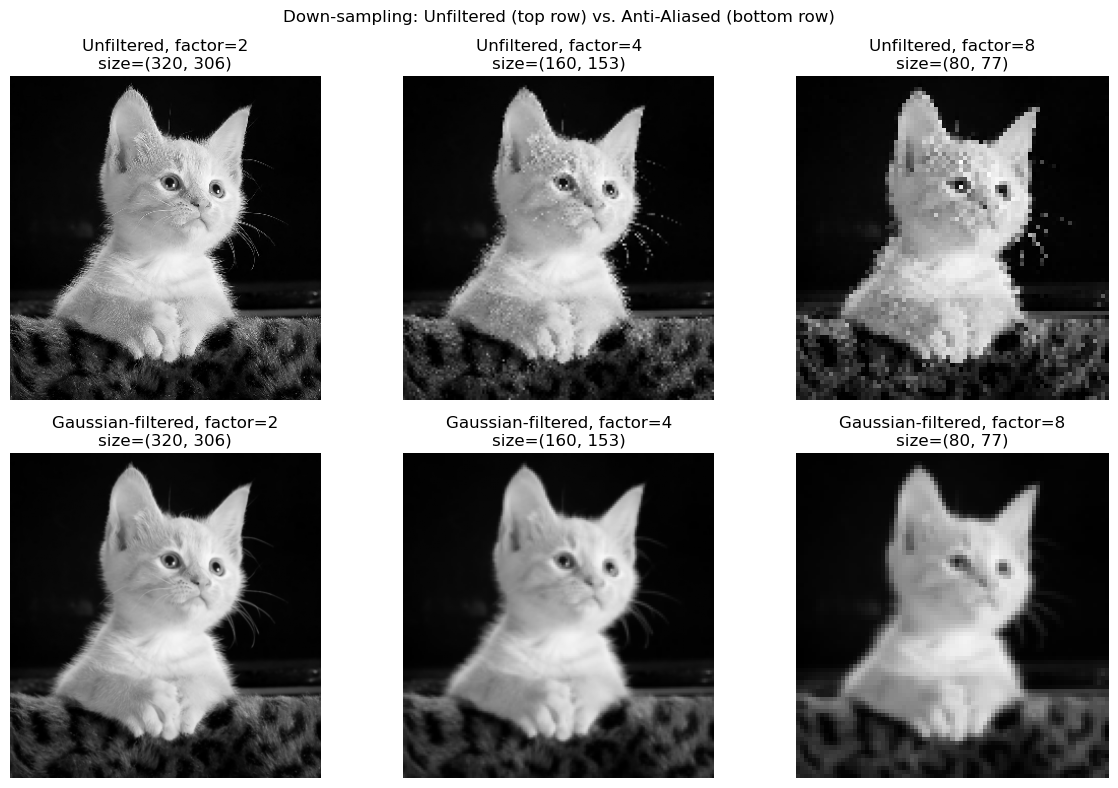

In [5]:
fig, axes = plt.subplots(2, len(factors), figsize=(4 * len(factors), 8))

for col, f in enumerate(factors):
    axes[0, col].imshow(unfiltered[f], cmap="gray", vmin=0, vmax=255)
    axes[0, col].set_title(f"Unfiltered, factor={f}\nsize={unfiltered[f].shape}")
    axes[0, col].axis("off")

    axes[1, col].imshow(filtered[f], cmap="gray", vmin=0, vmax=255)
    axes[1, col].set_title(f"Gaussian-filtered, factor={f}\nsize={filtered[f].shape}")
    axes[1, col].axis("off")

fig.suptitle("Down-sampling: Unfiltered (top row) vs. Anti-Aliased (bottom row)")
fig.tight_layout()
plt.show()

## (v) Up-Sampling & Quantitative Evaluation (MSE & PSNR vs. Original)


In [6]:
def mse(a: np.ndarray, b: np.ndarray) -> float:
    a = a.astype(np.float64)
    b = b.astype(np.float64)
    return float(np.mean((a - b) ** 2))


def psnr(mse_value: float, max_pixel: float = 255.0) -> float:
    if mse_value == 0:
        return float("inf")
    return 10.0 * np.log10((max_pixel**2) / mse_value)


results = []  # (label, factor, mse, psnr)

for f in factors:
    up_unfiltered = cv2.resize(unfiltered[f], (W, H), interpolation=cv2.INTER_NEAREST)
    up_filtered = cv2.resize(filtered[f], (W, H), interpolation=cv2.INTER_NEAREST)

    m_u = mse(img, up_unfiltered)
    p_u = psnr(m_u)
    results.append(("Unfiltered", f, m_u, p_u))

    m_f = mse(img, up_filtered)
    p_f = psnr(m_f)
    results.append(("Filtered (anti-aliased)", f, m_f, p_f))

print(f"{'Method':<26}{'Factor':>8}{'MSE':>14}{'PSNR (dB)':>14}")
print("-" * 62)
for label, f, m, p in results:
    p_str = f"{p:.2f}" if np.isfinite(p) else "inf"
    print(f"{label:<26}{f:>8}{m:>14.3f}{p_str:>14}")

Method                      Factor           MSE     PSNR (dB)
--------------------------------------------------------------
Unfiltered                       2       162.298         26.03
Filtered (anti-aliased)          2       114.784         27.53
Unfiltered                       4       322.416         23.05
Filtered (anti-aliased)          4       205.642         25.00
Unfiltered                       8       507.035         21.08
Filtered (anti-aliased)          8       328.299         22.97


## (vi) Discussion: Anti-Aliasing & Nyquist Criterion

Across all three factors, the **Gaussian-filtered (anti-aliased)** down-sampling gives a lower MSE and a higher PSNR than direct pixel skipping.

### Key Insights:

1. **Nyquist Criterion Violation:** Unfiltered down-sampling violates the Nyquist sampling theorem. By discarding pixels directly without low-pass filtering, high spatial frequencies that exceed the new Nyquist limit ($f_s / 2$) are not removed.
2. **Aliasing Artifacts:** These un-attenuated high frequencies fold back into lower frequency bands, appearing as visible aliasing artifacts (moiré patterns, false textures, and jagged edges).
3. **Role of Gaussian Low-Pass Filter:** Pre-filtering with a Gaussian kernel attenuates frequencies above the new Nyquist limit prior to sub-sampling. Even though low-pass filtering intentionally removes fine detail (blurring), it prevents false low-frequency distortion. Consequently, the reconstructed image is a smoother, mathematically closer approximation of the original image (yielding higher PSNR).
